# A first look at gas-turbine emissions data

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/foundations/02-gas-turbine-data.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

This notebook develops an exploratory data analysis (EDA) workflow for our primary recurring dataset. Before fitting a model, engineers should understand what was measured, which values are plausible, and which patterns deserve further investigation.

**Learning objectives**

- Inspect a dataset for size, variable types, missing values, and plausible ranges.
- Summarize measurements before deciding which patterns need a plot.
- Use plots to answer physical questions about a system.
- Distinguish an observed association from a causal conclusion.

## 1. Load the data

You loaded this dataset in the previous notebook. Run the setup cell below to make this notebook self-contained, then use it to ask four EDA questions: What is in the table? Are the values usable? What does NOx look like? Which associations deserve a closer look?

In [1]:
# This setup cell is repeated so the notebook also runs independently in Colab.
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.request import urlretrieve

# Use a consistent visual style across the course notebooks.
plt.style.use("seaborn-v0_8-whitegrid")

# Point to the documented course version, rather than a changing external source.
DATA_URL = (
    "https://raw.githubusercontent.com/changyaochen/MECE4520/master/"
    "site/data/gas-turbine-course.csv"
)
# Prefer a nearby file when working locally; download the same file in a fresh runtime.
data_path = next(
    (path for path in [Path("../data/gas-turbine-course.csv"), Path("site/data/gas-turbine-course.csv"), Path("gas-turbine-course.csv")] if path.exists()),
    Path("gas-turbine-course.csv"),
)
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)
data = pd.read_csv(data_path)
data.head()

,campaign_year,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,2011,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,0.32663,81.952
1,2011,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,0.44784,82.377
2,2011,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,0.45144,83.776
3,2011,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,0.23107,82.505
4,2011,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,0.26747,82.028


## 2. Inspect the table

Start with a quick audit before interpreting any pattern. We want to confirm the dataset has the expected number of observations and variables, identify missing values, and notice whether a variable is continuous or nearly categorical.

In [2]:
# Check the basic shape before assuming one row means what we think it means.
print(f"Observations: {data.shape[0]:,}")
print(f"Variables: {data.shape[1]}")

# Build a compact audit table for types, missing values, and measurement resolution.
summary = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "unique values": data.nunique(),
})
summary

Observations: 36,733
Variables: 12


,dtype,missing,unique values
campaign_year,int64,0,5
AT,float64,0,22523
AP,float64,0,791
AH,float64,1102,25183
AFDP,float64,240,20425
GTEP,float64,0,12967
TIT,float64,0,799
TAT,float64,0,2769
TEY,float64,0,6236
CDP,float64,0,4447


There are no missing values in this version of the dataset. That is made specially so for teaching/learning purpose, but it should not be treated as normal: checking missingness is an essential first step in every real analysis, and real world data almost always has missing values!

**Try it:** Which column has the fewest unique values? Does that make it a categorical variable, or could it still be a rounded numerical measurement?

In [3]:
# Show the columns with the fewest distinct values.
# data.nunique().sort_values().head()

# Inspect the values in one candidate column before deciding how to treat it.
# data["<COLUMN_NAME>"].value_counts().head()

## 3. Summarize key measurements

Next ask: what operating ranges does this turbine occupy? The mean alone is rarely enough; the standard deviation and quantiles show how much a measurement varies across observed conditions and help reveal implausible values.

In [4]:
# Focus the first summary on interpretable ambient, turbine, energy, and emissions variables.
key_variables = ["AT", "AP", "AH", "TIT", "TEY", "CO", "NOX"]
data[key_variables].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]

,mean,std,min,25%,50%,75%,max
AT,17.712726,7.447451,-6.234800,11.7810,17.8010,23.6650,37.103
AP,1013.070165,6.463346,985.850000,1008.8000,1012.6000,1017.0000,1036.600
AH,77.877059,14.468821,24.085000,68.2115,80.4880,89.3920,100.200
TIT,1081.428084,17.536373,1000.800000,1071.8000,1085.9000,1097.0000,1100.900
TEY,133.506404,15.618634,100.020000,124.4500,133.7300,144.0800,179.500
CO,2.372468,2.262672,0.000388,1.1824,1.7135,2.8429,44.103
NOX,65.293067,11.678357,25.905000,57.1620,63.8490,71.5480,119.910


## 4. Ask a distribution question

Our question is: **how common are high-NOx operating hours?** A histogram shows how frequently a range of values occurs. If the distribution is not symmetric, reporting only a mean can hide useful information about high-emission observations.

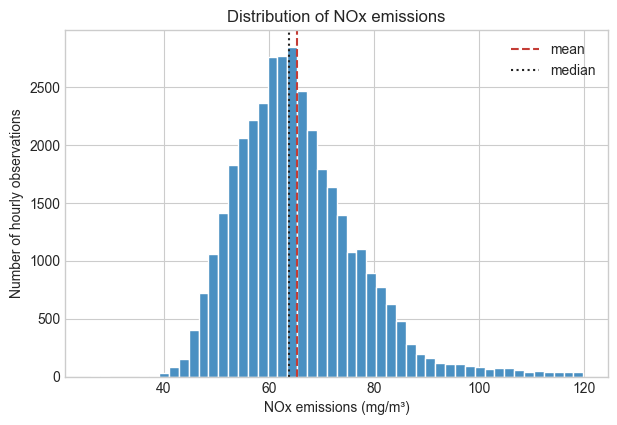

In [5]:
# Compare the mean and median to see whether a single center summarizes NOx well.
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(data["NOX"], bins=50, color="#4a90c2", edgecolor="white")
ax.axvline(data["NOX"].mean(), color="#c43c35", linestyle="--", label="mean")
ax.axvline(data["NOX"].median(), color="#222222", linestyle=":", label="median")
ax.set(xlabel="NOx emissions (mg/m³)", ylabel="Number of hourly observations", title="Distribution of NOx emissions")
ax.legend()
plt.show()

### A compact view: boxplot

A boxplot compresses the same distribution into a few robust summaries. The line inside the box is the median, and the box spans the middle 50% of observations (the interquartile range, IQR). By the usual 1.5 × IQR convention used here, each whisker reaches the most extreme observed value still within 1.5 IQR below the first quartile or above the third quartile; points beyond the whiskers are potential outliers. Boxplots are especially useful when comparing distributions across variables or operating groups later in the course.

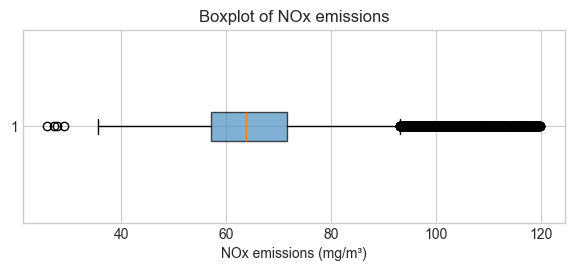

In [6]:
# A horizontal boxplot makes the center, spread, and unusually high NOx values easy to compare.
fig, ax = plt.subplots(figsize=(7, 2.5))
ax.boxplot(
    data["NOX"],
    vert=False,
    patch_artist=True,
    boxprops={"facecolor": "#4a90c2", "alpha": 0.7},
)
ax.set(xlabel="NOx emissions (mg/m³)", title="Boxplot of NOx emissions")
plt.show()

## 5. Screen for associations

Now ask: **which measurements move together strongly enough to investigate?** A correlation heatmap is a compact screen for linear associations. It helps us choose questions and plots; it does not establish a causal mechanism, because sensors can respond to the same operating state.

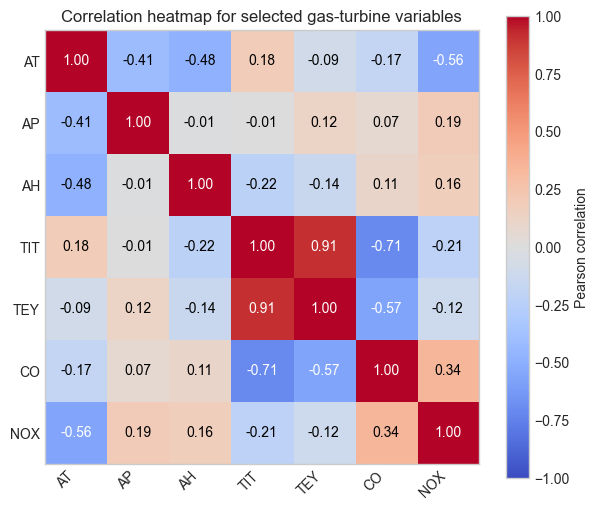

In [7]:
# Correlations describe linear association; they do not establish a causal mechanism.
correlations = data[key_variables].corr(numeric_only=True)

# A shared color scale makes strong positive and negative associations easy to spot.
fig, ax = plt.subplots(figsize=(7, 6))
heatmap = ax.imshow(correlations, cmap="coolwarm", vmin=-1, vmax=1)
# Disable the notebook-wide white grid so it does not draw over the heatmap cells.
ax.grid(False)

ax.set_xticks(range(len(key_variables)), key_variables, rotation=45, ha="right")
ax.set_yticks(range(len(key_variables)), key_variables)
ax.set_title("Correlation heatmap for selected gas-turbine variables")

# Label each cell so the heatmap remains useful when printed or viewed in grayscale.
for row in range(len(key_variables)):
    for column in range(len(key_variables)):
        value = correlations.iloc[row, column]
        text_color = "white" if abs(value) > 0.5 else "black"
        ax.text(column, row, f"{value:.2f}", ha="center", va="center", color=text_color)

fig.colorbar(heatmap, ax=ax, label="Pearson correlation")
plt.show()

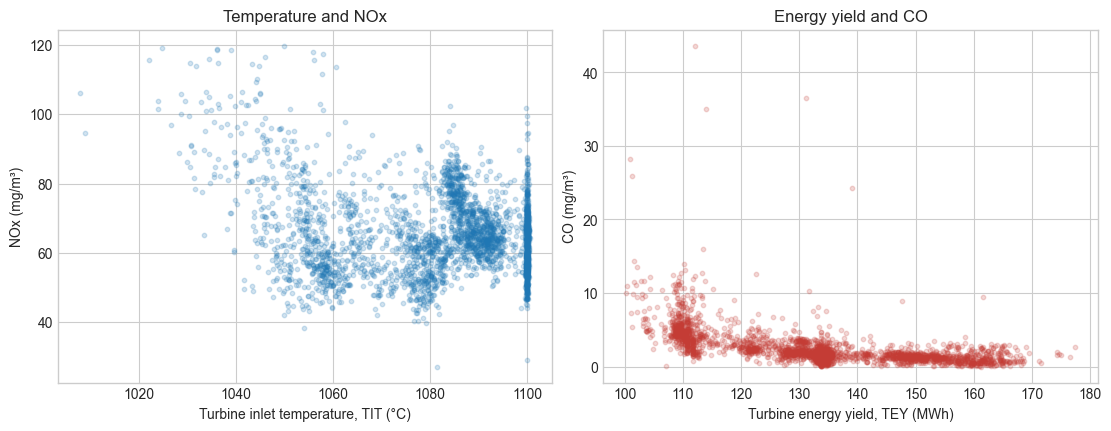

In [8]:
# Use a fixed random subset to keep the scatter plots legible and reproducible.
plot_data = data.sample(n=3_000, random_state=4520)

# Inspect two candidate associations visually before drawing conclusions from a correlation value.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
axes[0].scatter(plot_data["TIT"], plot_data["NOX"], alpha=0.2, s=10)
axes[0].set(xlabel="Turbine inlet temperature, TIT (°C)", ylabel="NOx (mg/m³)", title="Temperature and NOx")

axes[1].scatter(plot_data["TEY"], plot_data["CO"], alpha=0.2, s=10, color="#c43c35")
axes[1].set(xlabel="Turbine energy yield, TEY (MWh)", ylabel="CO (mg/m³)", title="Energy yield and CO")

plt.show()

## Check-in

1. What is one range or summary statistic that you would check for plausibility with an engineer familiar with this turbine?
2. Which variable has the most obvious association with NOx in the plots or correlation table?
3. What operating conditions might create a relationship between two sensors even if neither directly causes the other?
4. Why might chronology matter when we later split these observations into training and test sets?

Keep your answers in your own notes. The next notebook uses the same measurements to study variability and statistical evidence.

[Return to the Foundations page](index.qmd)